# Exploratory Data Analysis – EIT Touch Classification

## Objectives

This notebook performs a comprehensive EDA on the EIT dataset and outputs **cleaned datasets** (both clean and noisy) to `data/cleaned/`. The pipeline:

1. **§1** – Load data and inspect duplicates
2. **§2** – Distribution analysis (normality testing)
3. **§3** – Feature normalisation to [-1, 1]
4. **§4** – Correlation analysis and redundant feature removal (|r| ≥ 0.75)
5. **§5** – Feature separability by mean and variance
6. **§6** – Dimensionality reduction (PCA, LDA, UMAP) with t-SNE visualisation
7. **§7** – Feature importance after dimensionality reduction
8. **§8** – Output cleaned datasets to `data/cleaned/`

### Normalisation Choice: Per-Feature Min-Max Scaling to [-1, 1]

**Reasoning:** EIT measurements are boundary voltage differences across electrode pairs. Each
electrode pair has a different sensitivity pattern (based on its position and the drive pattern),
so features have heterogeneous scales. Per-feature Min-Max scaling:
- Preserves the **sign** of voltage changes (positive = conductivity decrease, negative = increase)
- Ensures each feature contributes equally regardless of its electrode pair’s baseline sensitivity
- Bounds the input to [-1, 1], which is suitable for neural networks with tanh-like activations
- Is grounded in the physics: each feature’s dynamic range corresponds to the physical sensitivity
  of that electrode pair to conductivity changes in the sensing region

In [1]:
import sys
sys.path.insert(0, '../python')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.io as sio
from scipy import stats
from scipy.spatial.distance import pdist, squareform

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import f_classif
from sklearn.metrics import silhouette_score

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("UMAP not installed. Install with: pip install umap-learn")

from data.load_dataset import load_mat_dataset

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')
%matplotlib inline

SEED = 42
DATA_PATH = Path('../data/eit_dataset.mat')
OUTPUT_DIR = Path('../data/cleaned')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['No contact', 'Light touch', 'Firm press', 'Point contact', 'Distributed']
N_CLASSES = len(CLASS_NAMES)
rng = np.random.default_rng(SEED)

print("Setup complete.")

Setup complete.


## §1 – Load Data and Inspect Duplicates

Check both clean and noisy datasets for exact and near-duplicate samples.

In [2]:
# Load datasets
X_clean, y = load_mat_dataset(DATA_PATH, use_noisy=False)
X_noisy, _ = load_mat_dataset(DATA_PATH, use_noisy=True)

print(f"Dataset shape: {X_clean.shape[0]} samples x {X_clean.shape[1]} features")
print(f"Classes: {N_CLASSES} ({', '.join(CLASS_NAMES)})")
print(f"Label range: [{y.min()}, {y.max()}]")
print(f"\nClean X: min={X_clean.min():.4f}, max={X_clean.max():.4f}, mean={X_clean.mean():.4f}")
print(f"Noisy X: min={X_noisy.min():.4f}, max={X_noisy.max():.4f}, mean={X_noisy.mean():.4f}")

# Class distribution
unique, counts = np.unique(y, return_counts=True)
class_df = pd.DataFrame({'Class': CLASS_NAMES, 'Count': counts, 'Fraction': counts / len(y)})
display(class_df)

Dataset shape: 25000 samples x 208 features
Classes: 5 (No contact, Light touch, Firm press, Point contact, Distributed)
Label range: [0, 4]

Clean X: min=-0.0082, max=0.0510, mean=0.0004
Noisy X: min=-0.0293, max=0.0573, mean=0.0004


,Class,Count,Fraction
0,No contact,5000,0.2
1,Light touch,5000,0.2
2,Firm press,5000,0.2
3,Point contact,5000,0.2
4,Distributed,5000,0.2


In [3]:
# --- Exact duplicates in clean data ---
_, unique_idx_clean, unique_counts_clean = np.unique(
    X_clean, axis=0, return_index=True, return_counts=True
)
n_dup_clean = len(X_clean) - len(unique_idx_clean)
print("=== Clean Data Duplicates ===")
print(f"Exact duplicate rows: {n_dup_clean} ({n_dup_clean/len(X_clean)*100:.1f}%)")
if n_dup_clean > 0:
    print(f"  Unique samples with copies: {(unique_counts_clean > 1).sum()}")
    print(f"  Max copies of a single sample: {unique_counts_clean.max()}")

# --- Exact duplicates in noisy data ---
_, unique_idx_noisy, unique_counts_noisy = np.unique(
    X_noisy, axis=0, return_index=True, return_counts=True
)
n_dup_noisy = len(X_noisy) - len(unique_idx_noisy)
print("\n=== Noisy Data Duplicates ===")
print(f"Exact duplicate rows: {n_dup_noisy} ({n_dup_noisy/len(X_noisy)*100:.1f}%)")
if n_dup_noisy > 0:
    print(f"  Unique samples with copies: {(unique_counts_noisy > 1).sum()}")
    print(f"  Max copies of a single sample: {unique_counts_noisy.max()}")

=== Clean Data Duplicates ===
Exact duplicate rows: 5798 (23.2%)
  Unique samples with copies: 1
  Max copies of a single sample: 5799

=== Noisy Data Duplicates ===
Exact duplicate rows: 0 (0.0%)


In [4]:
# --- Near-duplicate detection (Euclidean distance < threshold) ---
n_check = min(3000, len(X_clean))
idx_check = rng.choice(len(X_clean), n_check, replace=False)

# Standardize for fair distance comparison
scaler_temp = StandardScaler()
X_check_clean = scaler_temp.fit_transform(X_clean[idx_check])
X_check_noisy = scaler_temp.transform(X_noisy[idx_check])

dists_clean = pdist(X_check_clean)
dists_noisy = pdist(X_check_noisy)

thresholds = [0.01, 0.05, 0.1]
print(f"Near-duplicate analysis (subsample of {n_check} samples):")
print(f"{'Threshold':<12} {'Clean pairs':<15} {'Noisy pairs':<15}")
print("-" * 42)
for t in thresholds:
    n_clean_pairs = (dists_clean < t).sum()
    n_noisy_pairs = (dists_noisy < t).sum()
    print(f"{t:<12.3f} {n_clean_pairs:<15} {n_noisy_pairs:<15}")

Near-duplicate analysis (subsample of 3000 samples):
Threshold    Clean pairs     Noisy pairs    
------------------------------------------
0.010        263179          0              
0.050        263198          0              
0.100        263210          0              


In [5]:
# Remove exact duplicates (keep first occurrence)
# Paired clean/noisy samples must stay aligned
# IMPORTANT: Keep ALL class 0 (No contact) samples unchanged
if n_dup_clean > 0:
    # Separate class 0 from other classes
    mask_class_0 = y == 0
    mask_other = y != 0
    
    # Keep all class 0 samples
    keep_idx_class_0 = np.where(mask_class_0)[0]
    
    # Remove duplicates from other classes only
    if mask_other.sum() > 0:
        _, unique_idx_other = np.unique(X_clean[mask_other], axis=0, return_index=True)
        # Convert back to original indices
        other_indices = np.where(mask_other)[0]
        keep_idx_other = other_indices[unique_idx_other]
    else:
        keep_idx_other = np.array([], dtype=int)
    
    # Combine and sort
    keep_idx = np.sort(np.concatenate([keep_idx_class_0, keep_idx_other]))
    
    X_clean = X_clean[keep_idx]
    X_noisy = X_noisy[keep_idx]
    y = y[keep_idx]
    n_dup_other = (mask_other.sum()) - keep_idx_other.shape[0]
    print(f"Removed {n_dup_other} duplicate samples (class 0 preserved with all {keep_idx_class_0.shape[0]} samples).")
    print(f"Dataset now: {X_clean.shape[0]} samples x {X_clean.shape[1]} features")
else:
    print("No duplicates found - no samples removed.")

# Updated class distribution
unique, counts = np.unique(y, return_counts=True)
print("\nClass distribution after deduplication:")
for name, count in zip(CLASS_NAMES, counts):
    print(f"  {name}: {count} ({count/len(y)*100:.1f}%)")

Removed 798 duplicate samples (class 0 preserved with all 5000 samples).
Dataset now: 24202 samples x 208 features

Class distribution after deduplication:
  No contact: 5000 (20.7%)
  Light touch: 5000 (20.7%)
  Firm press: 5000 (20.7%)
  Point contact: 4202 (17.4%)
  Distributed: 5000 (20.7%)


## §2 – Distribution Analysis

Test whether features are normally distributed. This informs normalisation choices
and whether parametric methods (e.g., LDA with Gaussian class-conditionals) are appropriate.

In [6]:
# Shapiro-Wilk test on a subset of features
n_features = X_clean.shape[1]
n_test_features = min(20, n_features)
test_features = rng.choice(n_features, n_test_features, replace=False)
test_features.sort()

# Subsample for Shapiro-Wilk (max 5000)
n_sw = min(5000, len(X_clean))
idx_sw = rng.choice(len(X_clean), n_sw, replace=False)

sw_results_clean = []
sw_results_noisy = []

for f in test_features:
    stat_c, p_c = stats.shapiro(X_clean[idx_sw, f])
    stat_n, p_n = stats.shapiro(X_noisy[idx_sw, f])
    sw_results_clean.append((f, stat_c, p_c))
    sw_results_noisy.append((f, stat_n, p_n))

n_normal_clean = sum(1 for _, _, p in sw_results_clean if p > 0.05)
n_normal_noisy = sum(1 for _, _, p in sw_results_noisy if p > 0.05)

print(f"Shapiro-Wilk normality test (alpha=0.05) on {n_test_features} features:")
print(f"  Clean: {n_normal_clean}/{n_test_features} features appear normally distributed")
print(f"  Noisy: {n_normal_noisy}/{n_test_features} features appear normally distributed")
not_normal = n_normal_clean < n_test_features // 2
print(f"\n-> {'Data is NOT normally distributed' if not_normal else 'Data appears approximately normal'}")

Shapiro-Wilk normality test (alpha=0.05) on 20 features:
  Clean: 0/20 features appear normally distributed
  Noisy: 0/20 features appear normally distributed

-> Data is NOT normally distributed


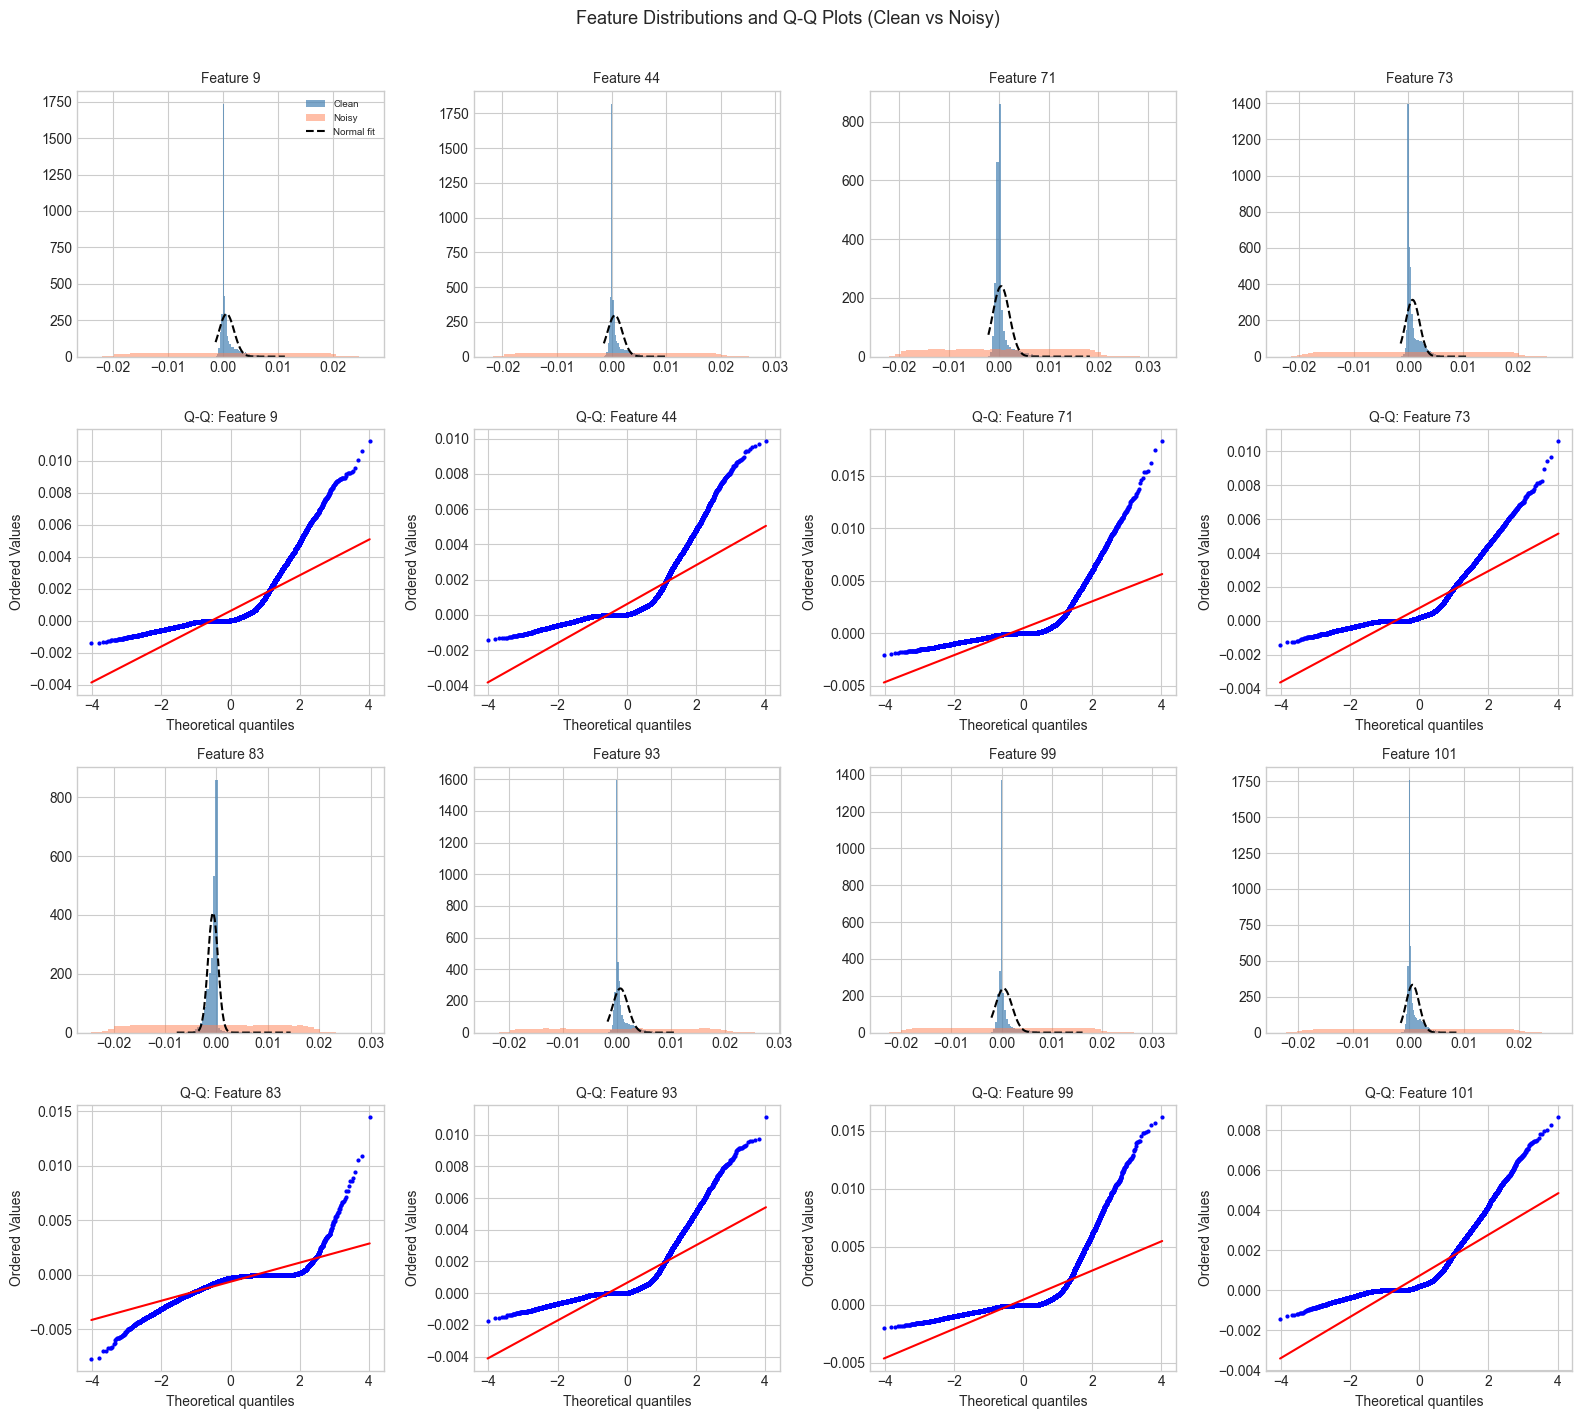

In [7]:
# Distribution plots: histograms + Q-Q plots for selected features
fig, axes = plt.subplots(4, 4, figsize=(16, 14))

sample_feats = test_features[:8]

for i, feat in enumerate(sample_feats):
    # Histogram
    ax_hist = axes[i // 4 * 2, i % 4]
    ax_hist.hist(X_clean[:, feat], bins=50, density=True, alpha=0.7, color='steelblue', label='Clean')
    ax_hist.hist(X_noisy[:, feat], bins=50, density=True, alpha=0.5, color='coral', label='Noisy')

    # Overlay normal fit
    mu, sigma = X_clean[:, feat].mean(), X_clean[:, feat].std()
    x_range = np.linspace(X_clean[:, feat].min(), X_clean[:, feat].max(), 100)
    ax_hist.plot(x_range, stats.norm.pdf(x_range, mu, sigma), 'k--', linewidth=1.5, label='Normal fit')
    ax_hist.set_title(f'Feature {feat}', fontsize=10)
    if i == 0:
        ax_hist.legend(fontsize=7)

    # Q-Q plot
    ax_qq = axes[i // 4 * 2 + 1, i % 4]
    stats.probplot(X_clean[:, feat], dist='norm', plot=ax_qq)
    ax_qq.set_title(f'Q-Q: Feature {feat}', fontsize=10)
    ax_qq.get_lines()[0].set_markersize(2)

fig.suptitle('Feature Distributions and Q-Q Plots (Clean vs Noisy)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

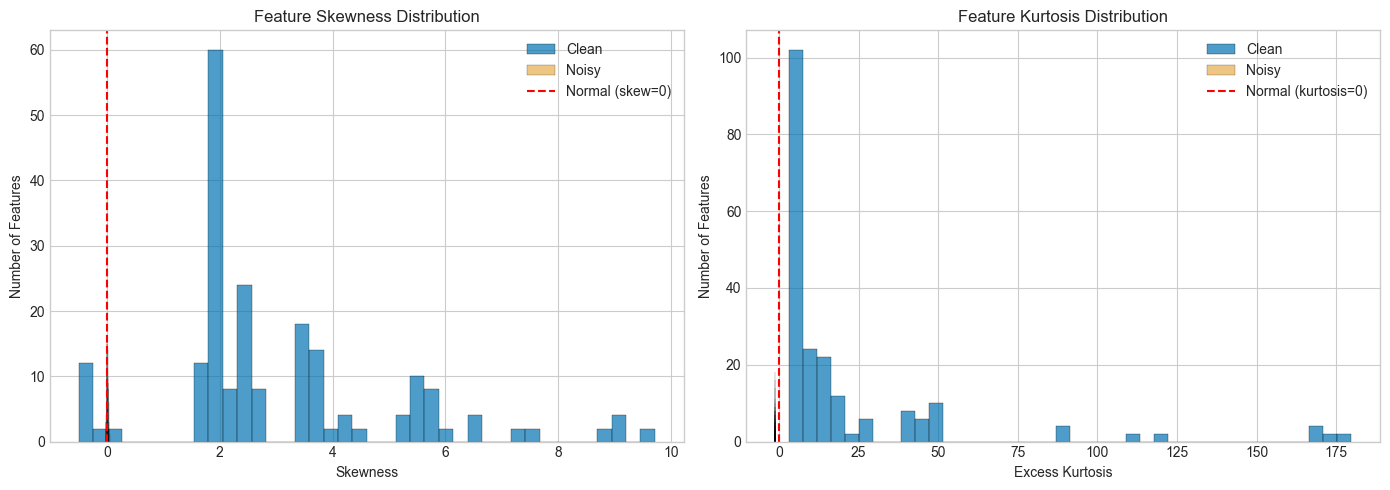


Skewness (Clean): mean=3.071, |skew|>1: 192 features
Kurtosis (Clean): mean=22.656, |kurt|>3: 208 features


In [8]:
# Skewness and Kurtosis analysis
skewness_clean = stats.skew(X_clean, axis=0)
kurtosis_clean = stats.kurtosis(X_clean, axis=0)
skewness_noisy = stats.skew(X_noisy, axis=0)
kurtosis_noisy = stats.kurtosis(X_noisy, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(skewness_clean, bins=40, alpha=0.7, label='Clean', edgecolor='black', linewidth=0.3)
axes[0].hist(skewness_noisy, bins=40, alpha=0.5, label='Noisy', edgecolor='black', linewidth=0.3)
axes[0].axvline(0, color='red', linestyle='--', label='Normal (skew=0)')
axes[0].set_xlabel('Skewness')
axes[0].set_ylabel('Number of Features')
axes[0].set_title('Feature Skewness Distribution')
axes[0].legend()

axes[1].hist(kurtosis_clean, bins=40, alpha=0.7, label='Clean', edgecolor='black', linewidth=0.3)
axes[1].hist(kurtosis_noisy, bins=40, alpha=0.5, label='Noisy', edgecolor='black', linewidth=0.3)
axes[1].axvline(0, color='red', linestyle='--', label='Normal (kurtosis=0)')
axes[1].set_xlabel('Excess Kurtosis')
axes[1].set_ylabel('Number of Features')
axes[1].set_title('Feature Kurtosis Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nSkewness (Clean): mean={skewness_clean.mean():.3f}, |skew|>1: {(np.abs(skewness_clean)>1).sum()} features")
print(f"Kurtosis (Clean): mean={kurtosis_clean.mean():.3f}, |kurt|>3: {(np.abs(kurtosis_clean)>3).sum()} features")

## §3 – Feature Normalisation to [-1, 1]

Apply per-feature Min-Max scaling to map each feature’s range to [-1, 1].

**Physics justification:** Each of the 208 EIT features corresponds to a specific electrode
drive/receive pattern. The sensitivity of each pattern depends on the geometry and the electrode
configuration. Per-feature scaling equalises contributions from all electrode pairs while
preserving the relative signal structure within each feature. The [-1, 1] range is chosen
because EIT differential measurements are naturally bipolar (conductivity can increase or
decrease relative to background), and this range is compatible with neural network architectures
using tanh activations.

In [9]:
# Fit scaler on clean data (ground truth), apply to both
scaler = MinMaxScaler(feature_range=(-1, 1))
X_clean_norm = scaler.fit_transform(X_clean)
X_noisy_norm = scaler.transform(X_noisy)

print("After normalisation:")
print(f"  Clean: min={X_clean_norm.min():.4f}, max={X_clean_norm.max():.4f}")
print(f"  Noisy: min={X_noisy_norm.min():.4f}, max={X_noisy_norm.max():.4f}")
print(f"  (Noisy may slightly exceed [-1,1] since scaler is fit on clean data)")

# Clip noisy to [-1, 1] to prevent outlier issues
n_clipped = ((X_noisy_norm < -1) | (X_noisy_norm > 1)).sum()
print(f"\n  Noisy values outside [-1,1]: {n_clipped} ({n_clipped / X_noisy_norm.size * 100:.2f}%)")
X_noisy_norm = np.clip(X_noisy_norm, -1, 1)

After normalisation:
  Clean: min=-1.0000, max=1.0000
  Noisy: min=-7.2309, max=6.3435
  (Noisy may slightly exceed [-1,1] since scaler is fit on clean data)

  Noisy values outside [-1,1]: 3057393 (60.73%)


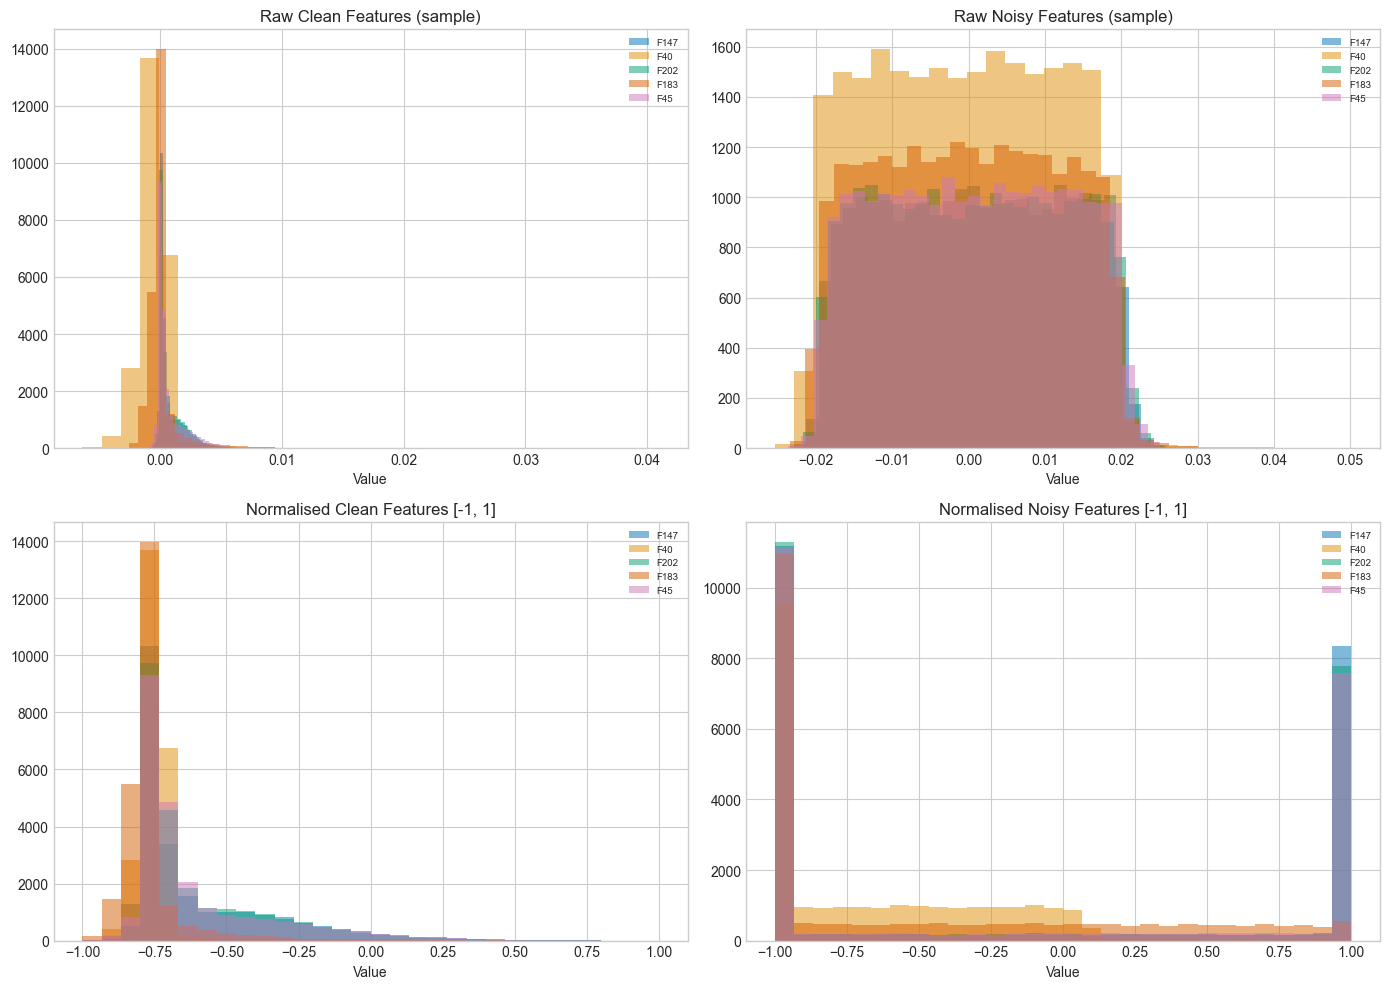

In [10]:
# Visualise before/after normalisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sample_feats_vis = rng.choice(n_features, 5, replace=False)
for f in sample_feats_vis:
    axes[0, 0].hist(X_clean[:, f], bins=30, alpha=0.5, label=f'F{f}')
axes[0, 0].set_title('Raw Clean Features (sample)')
axes[0, 0].set_xlabel('Value')
axes[0, 0].legend(fontsize=7)

for f in sample_feats_vis:
    axes[0, 1].hist(X_noisy[:, f], bins=30, alpha=0.5, label=f'F{f}')
axes[0, 1].set_title('Raw Noisy Features (sample)')
axes[0, 1].set_xlabel('Value')
axes[0, 1].legend(fontsize=7)

for f in sample_feats_vis:
    axes[1, 0].hist(X_clean_norm[:, f], bins=30, alpha=0.5, label=f'F{f}')
axes[1, 0].set_title('Normalised Clean Features [-1, 1]')
axes[1, 0].set_xlabel('Value')
axes[1, 0].legend(fontsize=7)

for f in sample_feats_vis:
    axes[1, 1].hist(X_noisy_norm[:, f], bins=30, alpha=0.5, label=f'F{f}')
axes[1, 1].set_title('Normalised Noisy Features [-1, 1]')
axes[1, 1].set_xlabel('Value')
axes[1, 1].legend(fontsize=7)

plt.tight_layout()
plt.show()

## §4 – Correlation Analysis and Redundant Feature Removal

Compute the correlation matrix between the 208 features. Features with |correlation| ≥ 0.75
are considered redundant. We remove the feature in each highly-correlated pair that has the
lower ANOVA F-statistic (i.e., less discriminative for the classification task).

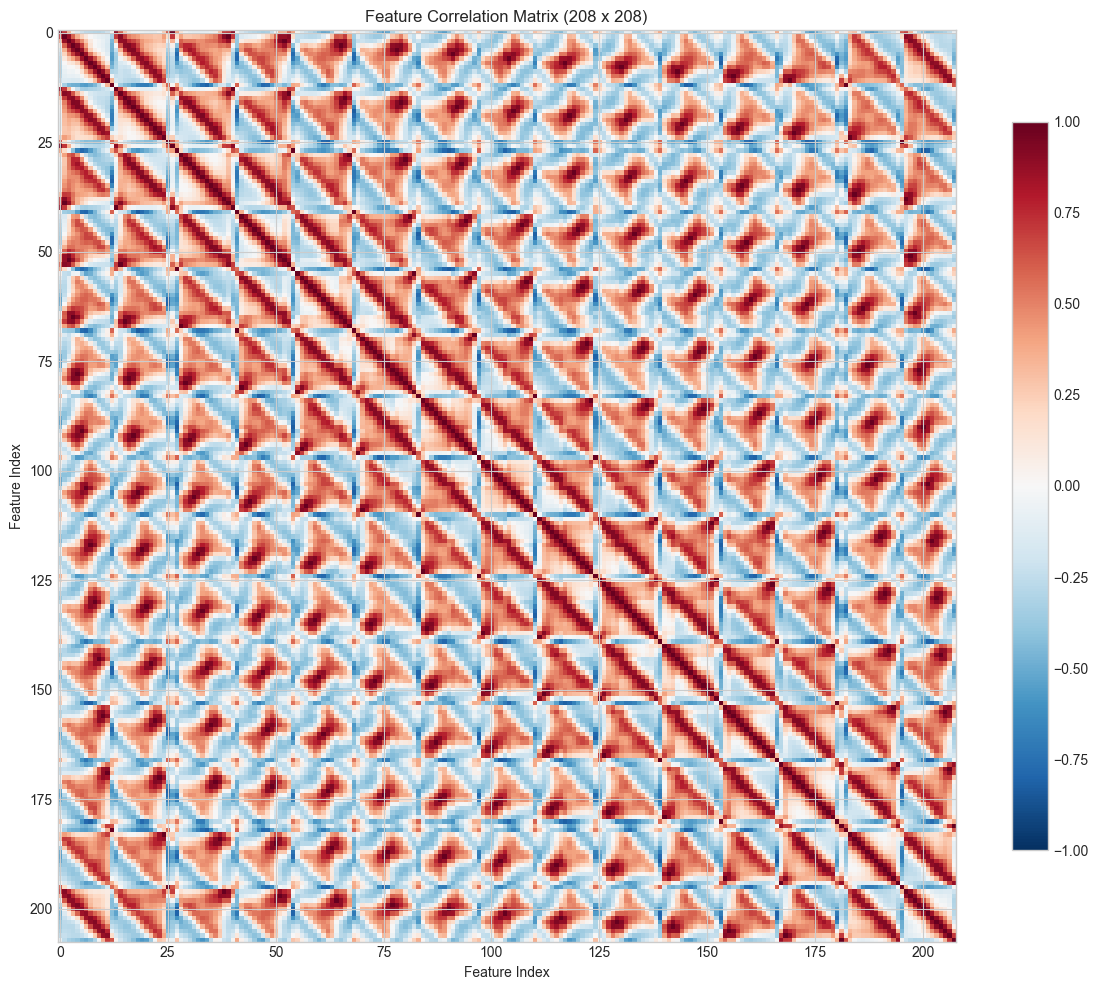


Correlation analysis:
  Feature pairs with |r| >= 0.75: 1628
  Feature pairs with |r| >= 0.90: 480
  Feature pairs with |r| >= 0.95: 104


In [11]:
# Correlation matrix
corr_matrix = np.corrcoef(X_clean_norm.T)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xlabel('Feature Index')
ax.set_ylabel('Feature Index')
ax.set_title(f'Feature Correlation Matrix ({n_features} x {n_features})')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

# Count highly correlated pairs
upper_tri = np.triu(np.abs(corr_matrix), k=1)
n_high_corr = (upper_tri >= 0.75).sum()
n_very_high_corr = (upper_tri >= 0.90).sum()
n_near_perfect = (upper_tri >= 0.95).sum()

print("\nCorrelation analysis:")
print(f"  Feature pairs with |r| >= 0.75: {n_high_corr}")
print(f"  Feature pairs with |r| >= 0.90: {n_very_high_corr}")
print(f"  Feature pairs with |r| >= 0.95: {n_near_perfect}")

In [12]:
# Identify and remove redundant features (|correlation| >= 0.75)
# Strategy: for each correlated pair, drop the feature with lower F-statistic

# ANOVA F-statistic for each feature (discriminative power)
f_stats, _ = f_classif(X_clean_norm, y)

features_to_drop = set()
n_original = X_clean_norm.shape[1]

for i in range(n_original):
    if i in features_to_drop:
        continue
    for j in range(i + 1, n_original):
        if j in features_to_drop:
            continue
        if abs(corr_matrix[i, j]) >= 0.75:
            # Drop the less discriminative feature
            if f_stats[i] < f_stats[j]:
                features_to_drop.add(i)
                break
            else:
                features_to_drop.add(j)

features_to_keep = sorted(set(range(n_original)) - features_to_drop)

print(f"Features to remove (|r| >= 0.75, lower F-stat): {len(features_to_drop)}")
print(f"Features retained: {len(features_to_keep)} / {n_original}")
print(f"\nDropped feature indices: {sorted(features_to_drop)}")

Features to remove (|r| >= 0.75, lower F-stat): 186
Features retained: 22 / 208

Dropped feature indices: [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 62, 63, 64, 65, 66, 68, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 88, 89, 91, 92, 93, 95, 96, 97, 98, 99, 100, 101, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 122, 124, 126, 127, 128, 129, 130, 131, 132, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 180, 182, 184, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 197, 198, 199, 200, 201, 202, 203, 205, 207]


Reduced dataset shape: (24202, 22)
Max |correlation| in reduced set: 0.7486


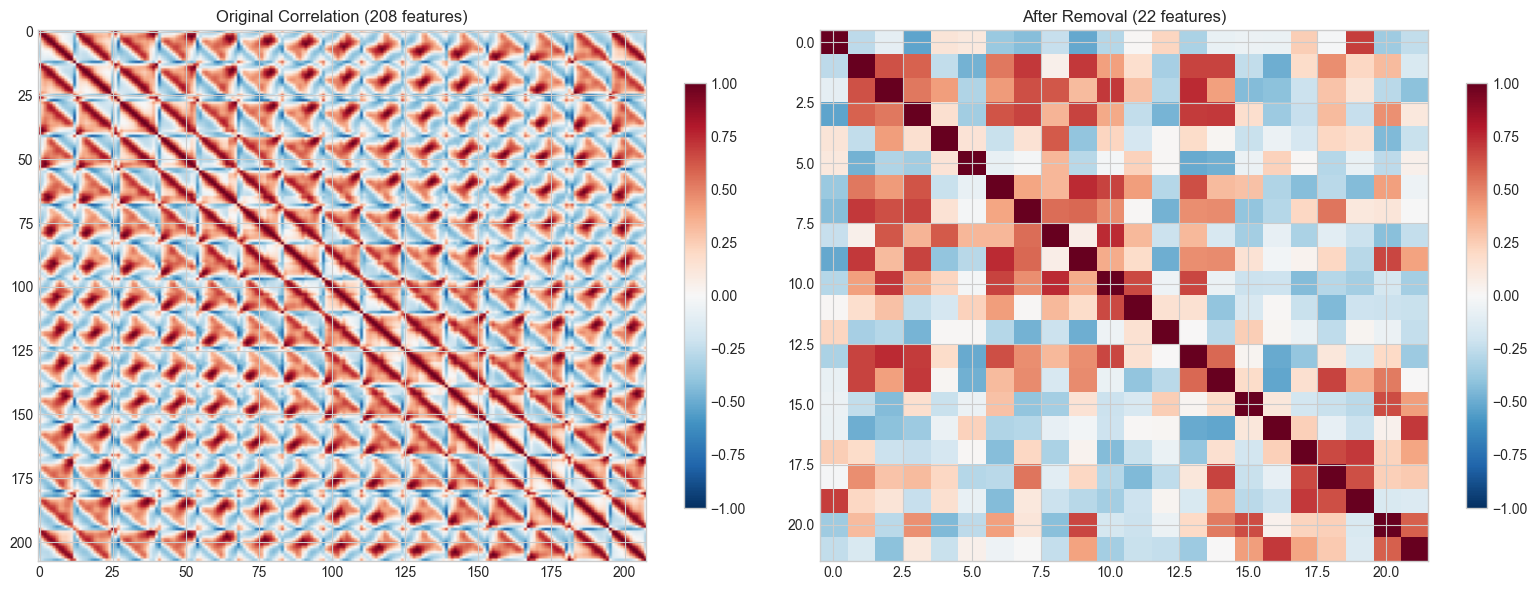

In [13]:
# Apply feature removal
X_clean_reduced = X_clean_norm[:, features_to_keep]
X_noisy_reduced = X_noisy_norm[:, features_to_keep]

print(f"Reduced dataset shape: {X_clean_reduced.shape}")

# Verify correlation is reduced
corr_reduced = np.corrcoef(X_clean_reduced.T)
upper_tri_reduced = np.triu(np.abs(corr_reduced), k=1)
max_corr_remaining = upper_tri_reduced.max()
print(f"Max |correlation| in reduced set: {max_corr_remaining:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = axes[0].imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title(f'Original Correlation ({n_original} features)')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(corr_reduced, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[1].set_title(f'After Removal ({len(features_to_keep)} features)')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

## §5 – Feature Separability by Mean and Variance

Investigate whether individual features can separate classes based on their
per-class mean or per-class variance.

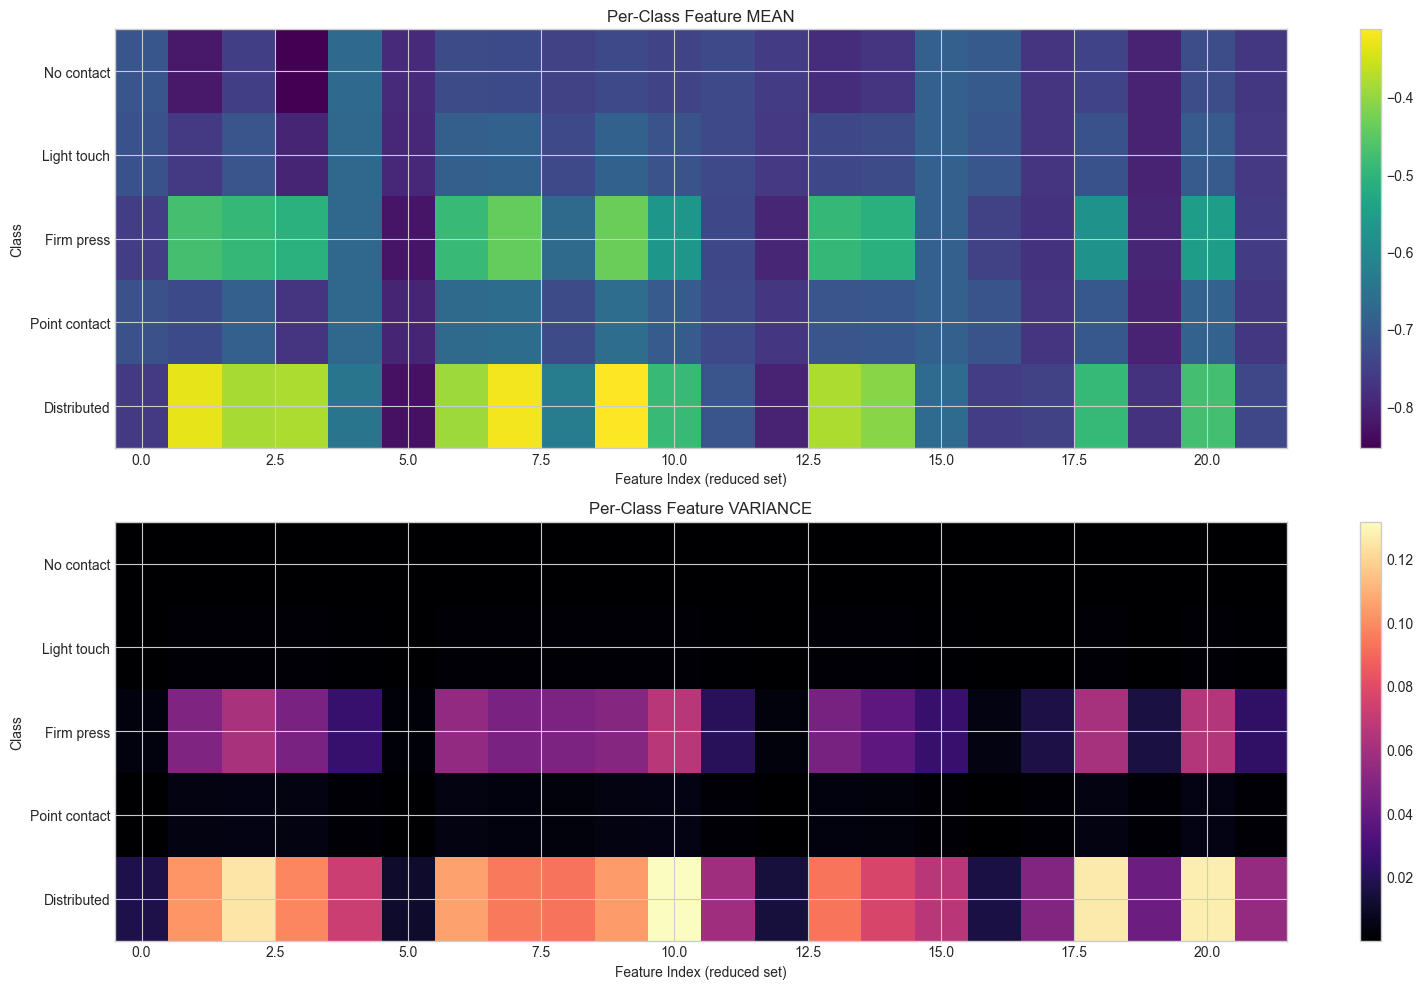

In [14]:
# Per-class mean and variance for each feature
class_means = np.array([X_clean_reduced[y == c].mean(axis=0) for c in range(N_CLASSES)])
class_stds = np.array([X_clean_reduced[y == c].std(axis=0) for c in range(N_CLASSES)])

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Mean heatmap
im0 = axes[0].imshow(class_means, aspect='auto', cmap='viridis')
axes[0].set_xlabel('Feature Index (reduced set)')
axes[0].set_ylabel('Class')
axes[0].set_yticks(range(N_CLASSES))
axes[0].set_yticklabels(CLASS_NAMES)
axes[0].set_title('Per-Class Feature MEAN')
plt.colorbar(im0, ax=axes[0])

# Variance heatmap
im1 = axes[1].imshow(class_stds**2, aspect='auto', cmap='magma')
axes[1].set_xlabel('Feature Index (reduced set)')
axes[1].set_ylabel('Class')
axes[1].set_yticks(range(N_CLASSES))
axes[1].set_yticklabels(CLASS_NAMES)
axes[1].set_title('Per-Class Feature VARIANCE')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

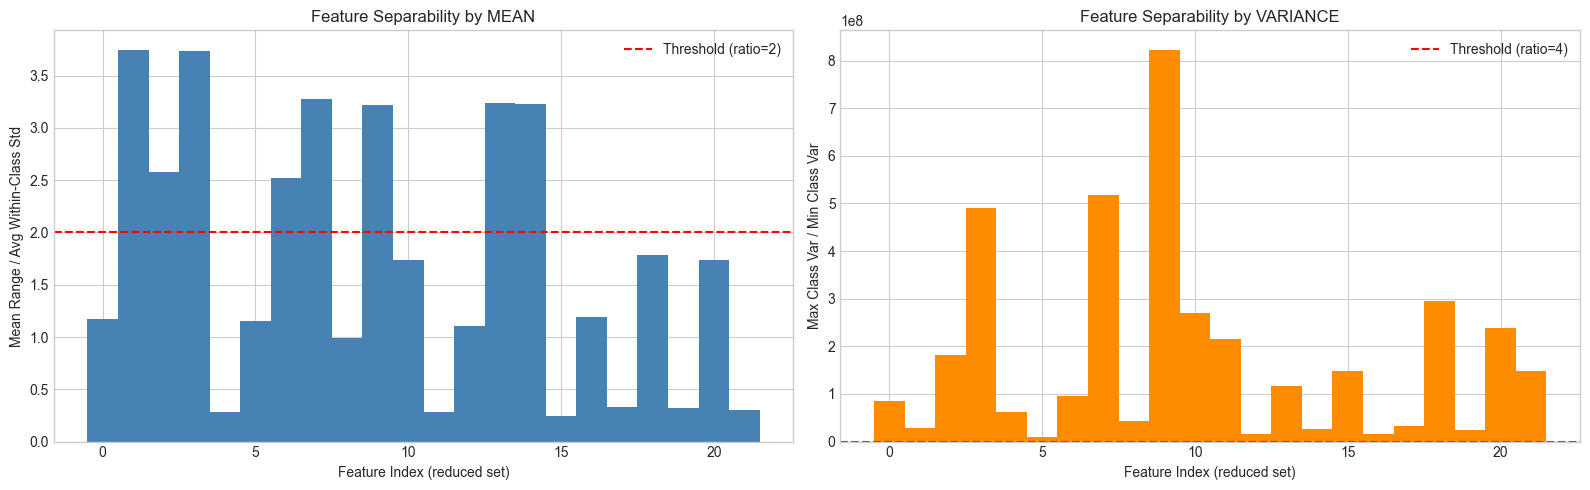


Features separable by mean (ratio > 2): 8 / 22
Features separable by variance (ratio > 4): 22 / 22


In [15]:
# Feature separability by mean (Fisher-like criterion)
mean_range = class_means.max(axis=0) - class_means.min(axis=0)
avg_within_std = class_stds.mean(axis=0)
mean_separability = mean_range / (avg_within_std + 1e-10)

# Feature separability by variance: ratio of max/min class variance
class_variances = class_stds**2
var_ratio = (class_variances.max(axis=0) + 1e-10) / (class_variances.min(axis=0) + 1e-10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(len(mean_separability)), mean_separability, width=1.0, color='steelblue')
axes[0].axhline(2.0, color='red', linestyle='--', label='Threshold (ratio=2)')
axes[0].set_xlabel('Feature Index (reduced set)')
axes[0].set_ylabel('Mean Range / Avg Within-Class Std')
axes[0].set_title('Feature Separability by MEAN')
axes[0].legend()

axes[1].bar(range(len(var_ratio)), var_ratio, width=1.0, color='darkorange')
axes[1].axhline(4.0, color='red', linestyle='--', label='Threshold (ratio=4)')
axes[1].set_xlabel('Feature Index (reduced set)')
axes[1].set_ylabel('Max Class Var / Min Class Var')
axes[1].set_title('Feature Separability by VARIANCE')
axes[1].legend()

plt.tight_layout()
plt.show()

n_mean_sep = (mean_separability > 2.0).sum()
n_var_sep = (var_ratio > 4.0).sum()
print(f"\nFeatures separable by mean (ratio > 2): {n_mean_sep} / {len(mean_separability)}")
print(f"Features separable by variance (ratio > 4): {n_var_sep} / {len(var_ratio)}")

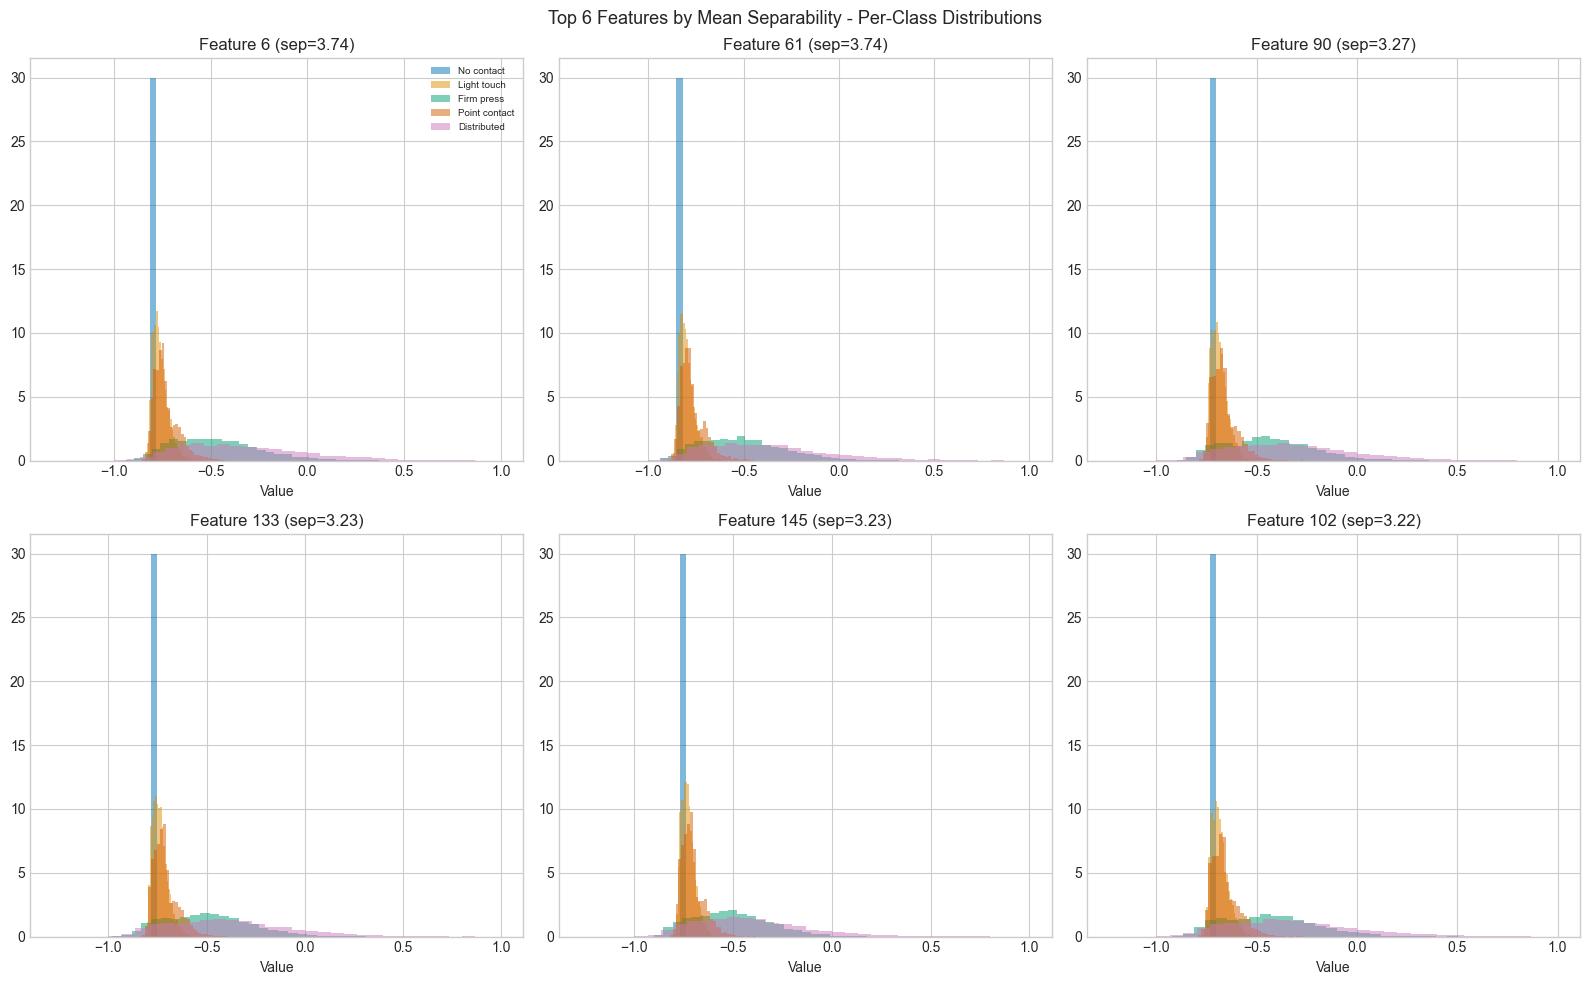

In [16]:
# Top features by mean separability - show per-class distributions
top_mean_feats = np.argsort(mean_separability)[-6:][::-1]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for idx, (ax, feat) in enumerate(zip(axes.ravel(), top_mean_feats)):
    for c in range(N_CLASSES):
        ax.hist(X_clean_reduced[y == c, feat], bins=30, alpha=0.5,
                label=CLASS_NAMES[c], density=True)
    ax.set_title(f'Feature {features_to_keep[feat]} (sep={mean_separability[feat]:.2f})')
    ax.set_xlabel('Value')
    if idx == 0:
        ax.legend(fontsize=7)

fig.suptitle('Top 6 Features by Mean Separability - Per-Class Distributions', fontsize=13)
plt.tight_layout()
plt.show()

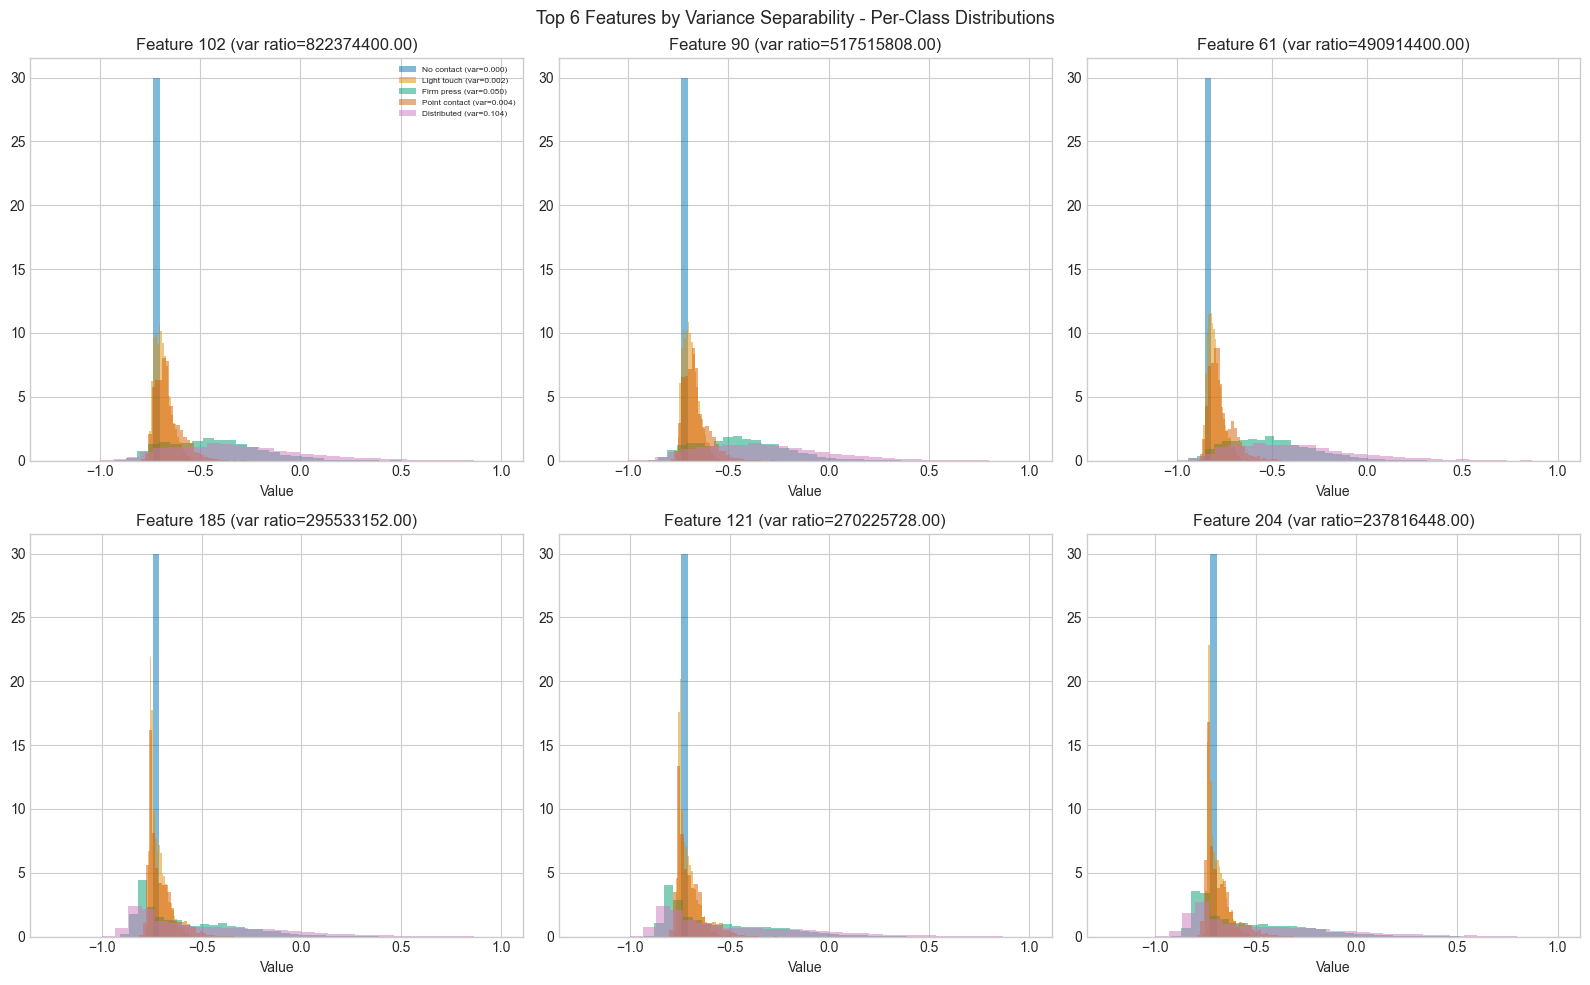

In [17]:
# Top features by variance separability
top_var_feats = np.argsort(var_ratio)[-6:][::-1]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for idx, (ax, feat) in enumerate(zip(axes.ravel(), top_var_feats)):
    for c in range(N_CLASSES):
        data = X_clean_reduced[y == c, feat]
        ax.hist(data, bins=30, alpha=0.5, label=f'{CLASS_NAMES[c]} (var={data.var():.3f})', density=True)
    ax.set_title(f'Feature {features_to_keep[feat]} (var ratio={var_ratio[feat]:.2f})')
    ax.set_xlabel('Value')
    if idx == 0:
        ax.legend(fontsize=6)

fig.suptitle('Top 6 Features by Variance Separability - Per-Class Distributions', fontsize=13)
plt.tight_layout()
plt.show()

## §6 – Dimensionality Reduction (PCA, LDA, UMAP) with t-SNE Visualisation

Apply each reduction method to the cleaned reduced features and visualise class separability
using t-SNE on the reduced representations.

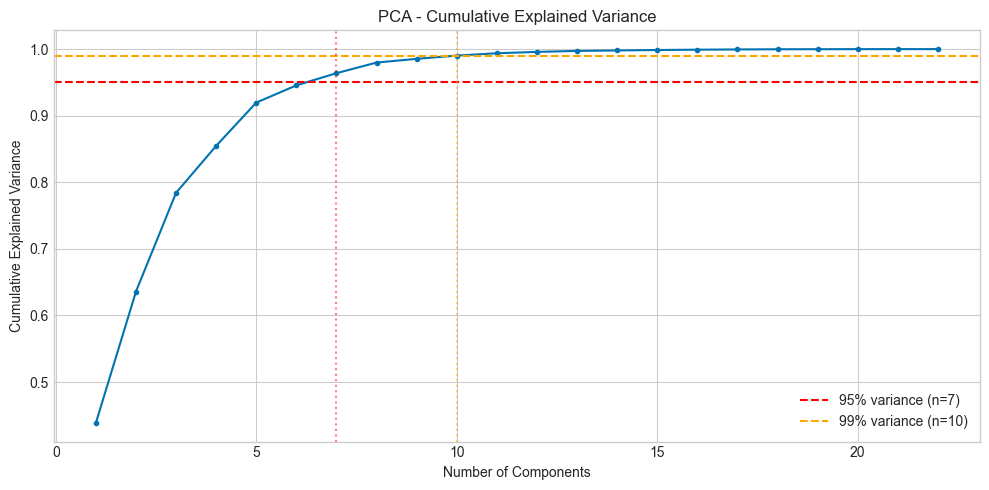

PCA components for 95% variance: 7
PCA components for 99% variance: 10
Using n_components = 7 (95% variance)


In [18]:
# --- PCA: determine optimal components via explained variance ---
pca_full = PCA(n_components=min(50, X_clean_reduced.shape[1]))
pca_full.fit(X_clean_reduced)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_pca_95 = np.argmax(cumvar >= 0.95) + 1
n_pca_99 = np.argmax(cumvar >= 0.99) + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar) + 1), cumvar, 'o-', markersize=3)
ax.axhline(0.95, color='red', linestyle='--', label=f'95% variance (n={n_pca_95})')
ax.axhline(0.99, color='orange', linestyle='--', label=f'99% variance (n={n_pca_99})')
ax.axvline(n_pca_95, color='red', linestyle=':', alpha=0.5)
ax.axvline(n_pca_99, color='orange', linestyle=':', alpha=0.5)
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA - Cumulative Explained Variance')
ax.legend()
plt.tight_layout()
plt.show()

print(f"PCA components for 95% variance: {n_pca_95}")
print(f"PCA components for 99% variance: {n_pca_99}")
print(f"Using n_components = {n_pca_95} (95% variance)")

In [19]:
# Apply PCA with optimal components
pca = PCA(n_components=n_pca_95, random_state=SEED)
X_clean_pca = pca.fit_transform(X_clean_reduced)
X_noisy_pca = pca.transform(X_noisy_reduced)

print(f"PCA output shape: {X_clean_pca.shape}")
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.4f}")

PCA output shape: (24202, 7)
Variance retained: 0.9638


In [20]:
# --- LDA: n_classes - 1 = 4 components (maximum for supervised) ---
n_lda_components = N_CLASSES - 1
lda = LDA(n_components=n_lda_components)
X_clean_lda = lda.fit_transform(X_clean_reduced, y)
X_noisy_lda = lda.transform(X_noisy_reduced)

print(f"LDA output shape: {X_clean_lda.shape}")
print(f"LDA explained variance ratios: {lda.explained_variance_ratio_}")
print(f"Total variance: {lda.explained_variance_ratio_.sum():.4f}")

LDA output shape: (24202, 4)
LDA explained variance ratios: [9.7131127e-01 2.8619749e-02 5.8018599e-05 1.0948471e-05]
Total variance: 1.0000


In [21]:
# --- UMAP ---
if HAS_UMAP:
    # Use moderate dimensionality for fair comparison
    n_umap_components = min(n_pca_95, 15)
    reducer = umap.UMAP(
        n_components=n_umap_components,
        random_state=SEED,
        n_neighbors=15,
        min_dist=0.1
    )
    X_clean_umap = reducer.fit_transform(X_clean_reduced)
    X_noisy_umap = reducer.transform(X_noisy_reduced)

    print(f"UMAP output shape: {X_clean_umap.shape}")
else:
    print("UMAP not available - skipping.")
    X_clean_umap = None
    X_noisy_umap = None
    n_umap_components = None

c:\Users\ronaldp\Documents\Repos\eit-sim2real\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ronaldp\Documents\Repos\eit-sim2real\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\ronaldp\Documents\Repos\eit-sim2real\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\ronaldp\Documents\Repos\eit-sim2real\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is like

UMAP output shape: (24202, 7)


In [22]:
# --- t-SNE visualisation of each reduced representation ---
n_tsne = min(5000, len(X_clean_reduced))
idx_tsne = rng.choice(len(X_clean_reduced), n_tsne, replace=False)

# t-SNE on original reduced features
print("Computing t-SNE on original features...")
tsne_original = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
X_tsne_original = tsne_original.fit_transform(X_clean_reduced[idx_tsne])

# t-SNE on PCA features
print("Computing t-SNE on PCA features...")
tsne_pca = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
X_tsne_pca = tsne_pca.fit_transform(X_clean_pca[idx_tsne])

# t-SNE on LDA features
print("Computing t-SNE on LDA features...")
tsne_lda = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
X_tsne_lda = tsne_lda.fit_transform(X_clean_lda[idx_tsne])

# t-SNE on UMAP features (if available)
if X_clean_umap is not None:
    print("Computing t-SNE on UMAP features...")
    tsne_umap = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
    X_tsne_umap = tsne_umap.fit_transform(X_clean_umap[idx_tsne])

print("t-SNE embeddings computed.")

Computing t-SNE on original features...
Computing t-SNE on PCA features...
Computing t-SNE on LDA features...
Computing t-SNE on UMAP features...
t-SNE embeddings computed.


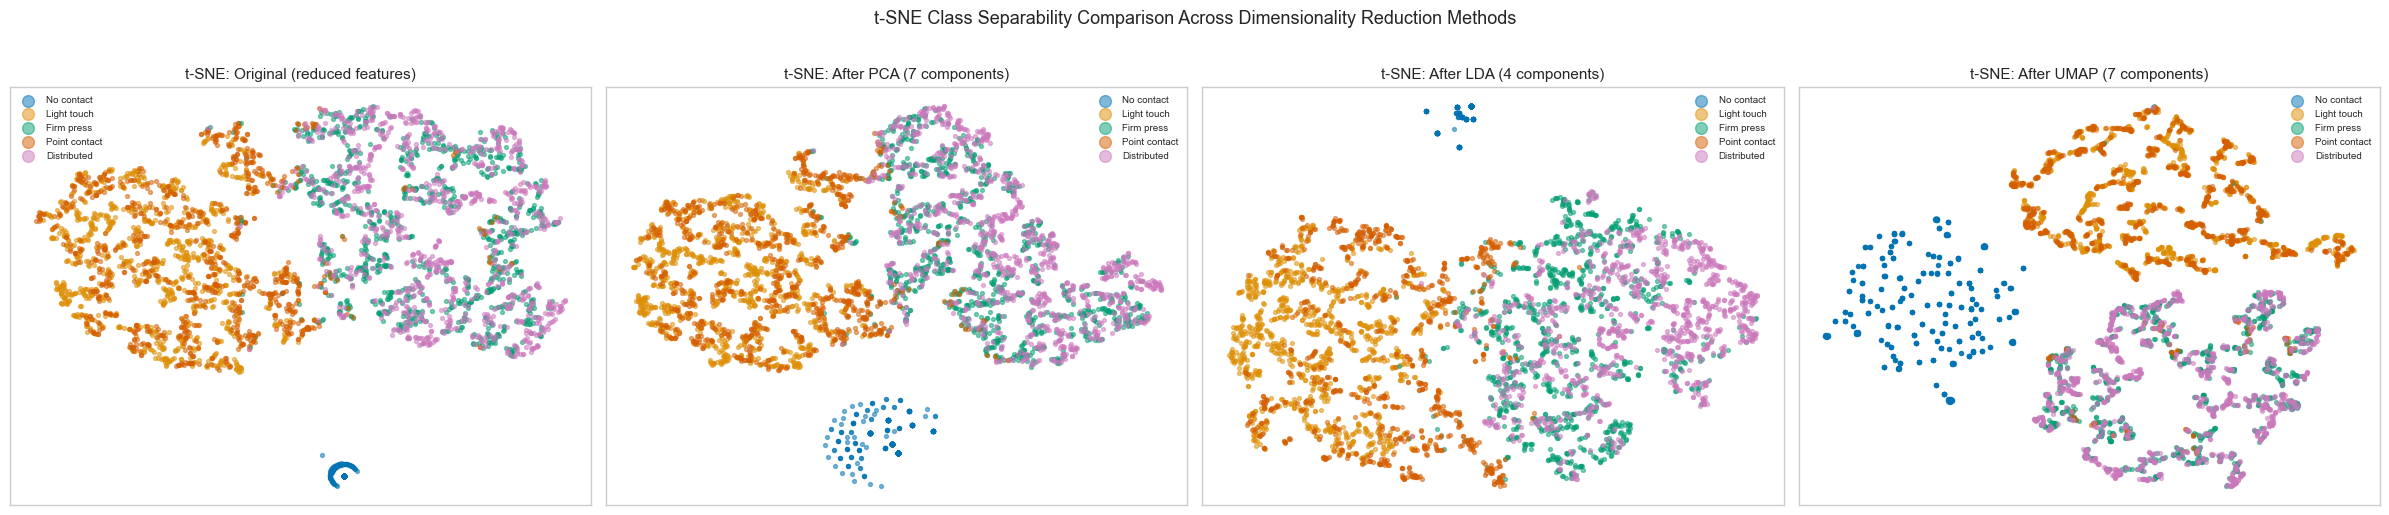

In [23]:
# Plot t-SNE comparisons
n_plots = 4 if X_clean_umap is not None else 3
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))

y_sub = y[idx_tsne]

datasets = [
    (X_tsne_original, 'Original (reduced features)'),
    (X_tsne_pca, f'After PCA ({n_pca_95} components)'),
    (X_tsne_lda, f'After LDA ({n_lda_components} components)'),
]
if X_clean_umap is not None:
    datasets.append((X_tsne_umap, f'After UMAP ({n_umap_components} components)'))

for ax, (X_embed, title) in zip(axes, datasets):
    for c in range(N_CLASSES):
        mask = y_sub == c
        ax.scatter(X_embed[mask, 0], X_embed[mask, 1],
                   label=CLASS_NAMES[c], alpha=0.5, s=8)
    ax.set_title(f't-SNE: {title}', fontsize=11)
    ax.legend(markerscale=3, fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('t-SNE Class Separability Comparison Across Dimensionality Reduction Methods',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# Quantitative separability: Silhouette score
sil_original = silhouette_score(X_tsne_original, y_sub)
sil_pca = silhouette_score(X_tsne_pca, y_sub)
sil_lda = silhouette_score(X_tsne_lda, y_sub)

print("Silhouette scores on t-SNE embeddings (higher = better class separation):")
print(f"  Original features:         {sil_original:.4f}")
print(f"  PCA ({n_pca_95} components):  {sil_pca:.4f}")
print(f"  LDA ({n_lda_components} components):           {sil_lda:.4f}")

if X_clean_umap is not None:
    sil_umap = silhouette_score(X_tsne_umap, y_sub)
    print(f"  UMAP ({n_umap_components} components): {sil_umap:.4f}")

# Also on the actual representations (not t-SNE)
print("\nSilhouette on actual reduced representations:")
n_sil = min(5000, len(X_clean_reduced))
idx_sil = rng.choice(len(X_clean_reduced), n_sil, replace=False)

sil_raw = silhouette_score(X_clean_reduced[idx_sil], y[idx_sil])
sil_pca_raw = silhouette_score(X_clean_pca[idx_sil], y[idx_sil])
sil_lda_raw = silhouette_score(X_clean_lda[idx_sil], y[idx_sil])

print(f"  Reduced features (no DR): {sil_raw:.4f}")
print(f"  PCA ({n_pca_95}D):            {sil_pca_raw:.4f}")
print(f"  LDA ({n_lda_components}D):             {sil_lda_raw:.4f}")

if X_clean_umap is not None:
    sil_umap_raw = silhouette_score(X_clean_umap[idx_sil], y[idx_sil])
    print(f"  UMAP ({n_umap_components}D):           {sil_umap_raw:.4f}")

print("\n-> Method with highest silhouette score provides best class separability.")

Silhouette scores on t-SNE embeddings (higher = better class separation):
  Original features:         0.2176
  PCA (7 components):  0.2099
  LDA (4 components):           0.2698
  UMAP (7 components): 0.1257

Silhouette on actual reduced representations:
  Reduced features (no DR): 0.0917
  PCA (7D):            0.0965
  LDA (4D):             0.1424
  UMAP (7D):           0.0451

-> Method with highest silhouette score provides best class separability.


## §7 – Feature Importance After Dimensionality Reduction

Understand which original features contribute most to the reduced representations.

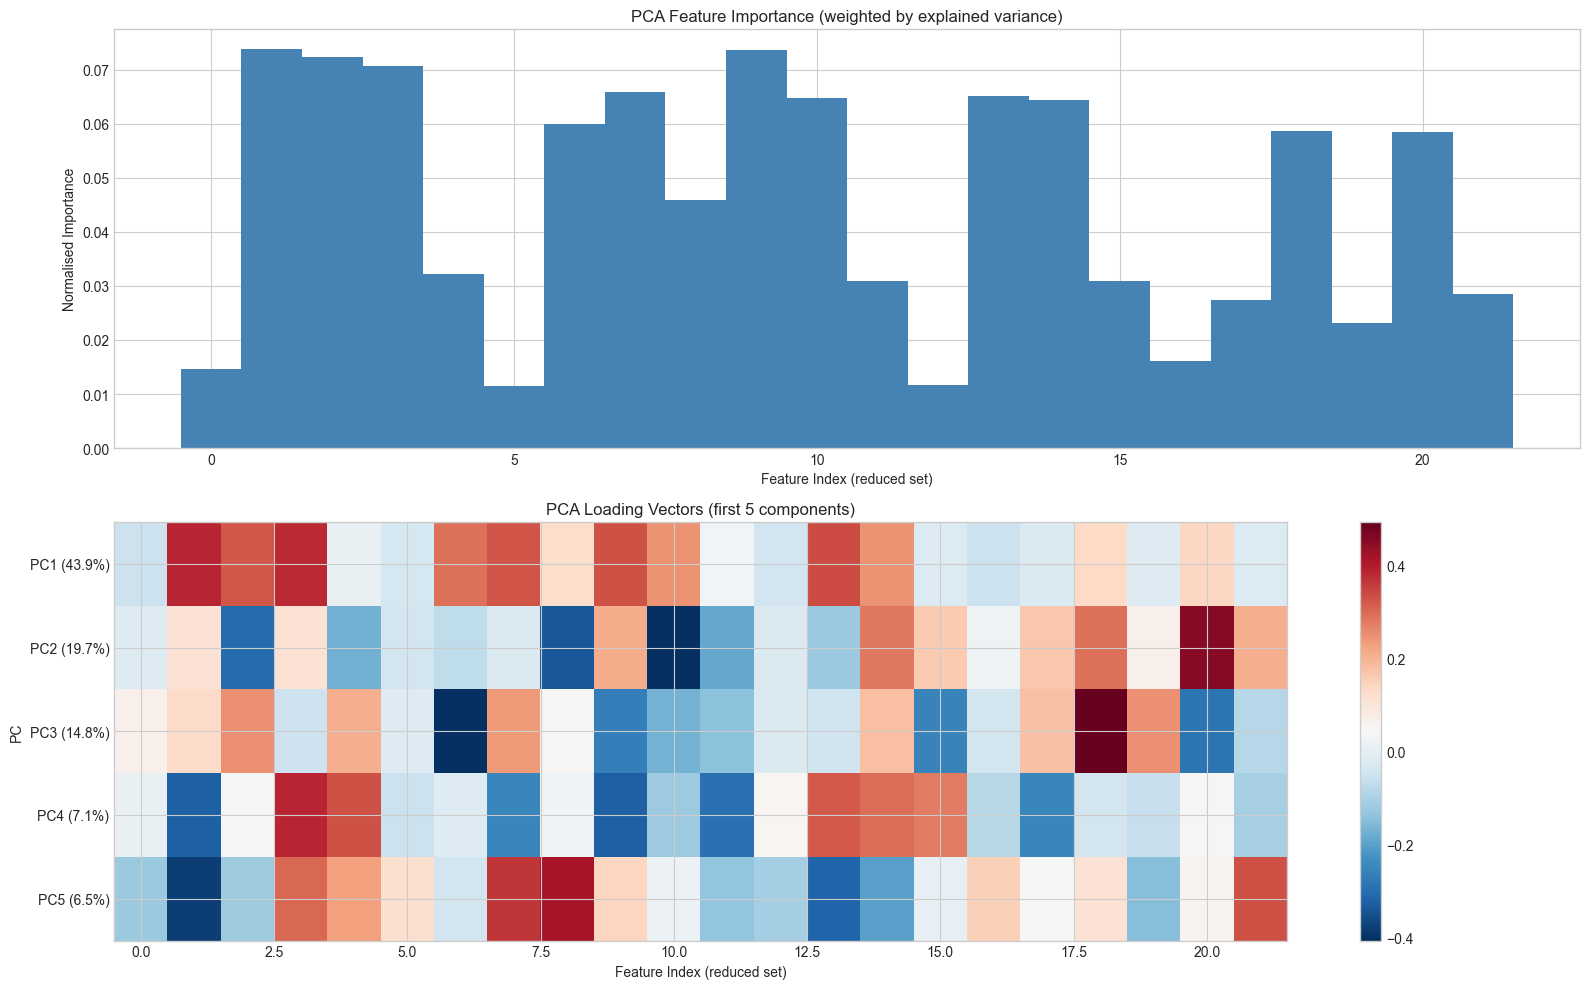


Top-10 PCA-important features (reduced idx): [ 1  9  2  3  7 13 10 14  6 18]
Top-10 PCA-important features (original idx): [6, 102, 31, 61, 90, 133, 121, 145, 87, 185]


In [25]:
# --- PCA: loading vectors show original feature contribution ---
pca_loadings = np.abs(pca.components_)  # (n_components, n_features)

# Weighted importance: sum of |loading| weighted by explained variance
pca_importance = (pca_loadings.T * pca.explained_variance_ratio_).sum(axis=1)
pca_importance /= pca_importance.sum()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].bar(range(len(pca_importance)), pca_importance, width=1.0, color='steelblue')
axes[0].set_xlabel('Feature Index (reduced set)')
axes[0].set_ylabel('Normalised Importance')
axes[0].set_title('PCA Feature Importance (weighted by explained variance)')

# Top PCA loading heatmap
n_show = min(5, pca.n_components_)
im = axes[1].imshow(pca.components_[:n_show], aspect='auto', cmap='RdBu_r')
axes[1].set_xlabel('Feature Index (reduced set)')
axes[1].set_ylabel('PC')
axes[1].set_yticks(range(n_show))
axes[1].set_yticklabels([f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})' for i in range(n_show)])
axes[1].set_title('PCA Loading Vectors (first 5 components)')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

top_pca_feats = np.argsort(pca_importance)[-10:][::-1]
print(f"\nTop-10 PCA-important features (reduced idx): {top_pca_feats}")
print(f"Top-10 PCA-important features (original idx): {[features_to_keep[i] for i in top_pca_feats]}")

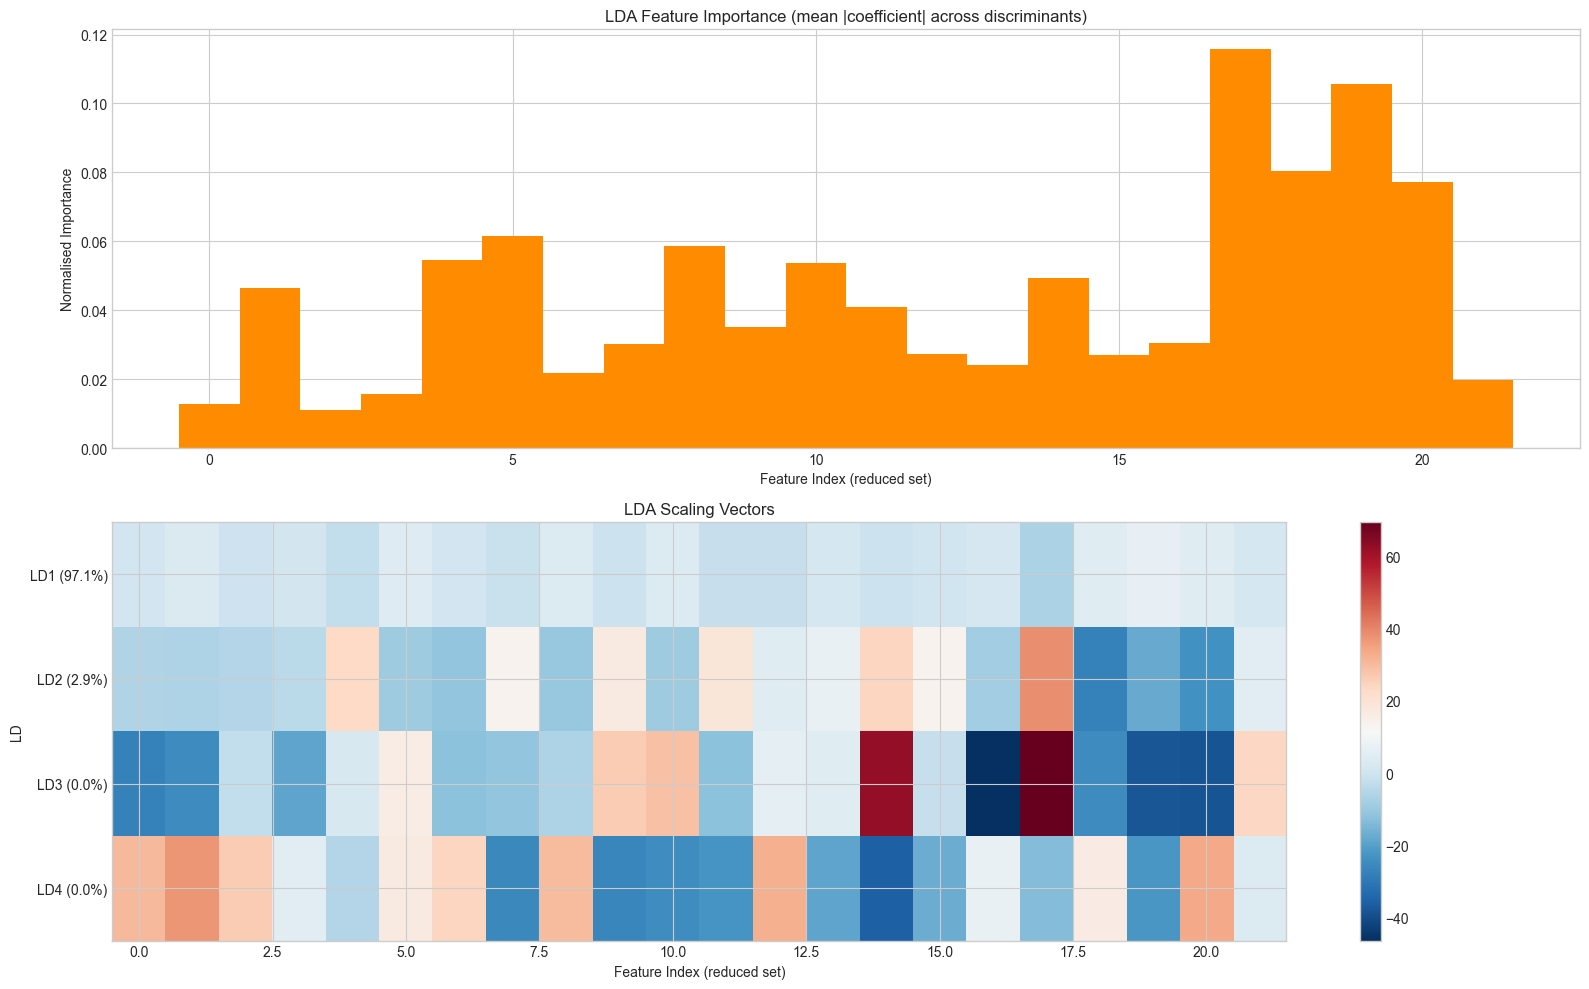


Top-10 LDA-important features (reduced idx): [17 19 18 20  5  8  4 10 14  1]
Top-10 LDA-important features (original idx): [183, 196, 185, 204, 69, 94, 67, 121, 145, 6]


In [26]:
# --- LDA: coefficient magnitudes show discriminative feature importance ---
lda_coefs = np.abs(lda.coef_)  # (n_classes, n_features)
lda_importance = lda_coefs.mean(axis=0)
lda_importance /= lda_importance.sum()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].bar(range(len(lda_importance)), lda_importance, width=1.0, color='darkorange')
axes[0].set_xlabel('Feature Index (reduced set)')
axes[0].set_ylabel('Normalised Importance')
axes[0].set_title('LDA Feature Importance (mean |coefficient| across discriminants)')

# LDA scalings heatmap
n_show_lda = min(4, lda.scalings_.shape[1])
im = axes[1].imshow(lda.scalings_[:, :n_show_lda].T, aspect='auto', cmap='RdBu_r')
axes[1].set_xlabel('Feature Index (reduced set)')
axes[1].set_ylabel('LD')
axes[1].set_yticks(range(n_show_lda))
axes[1].set_yticklabels([f'LD{i+1} ({lda.explained_variance_ratio_[i]:.1%})' for i in range(n_show_lda)])
axes[1].set_title('LDA Scaling Vectors')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

top_lda_feats = np.argsort(lda_importance)[-10:][::-1]
print(f"\nTop-10 LDA-important features (reduced idx): {top_lda_feats}")
print(f"Top-10 LDA-important features (original idx): {[features_to_keep[i] for i in top_lda_feats]}")

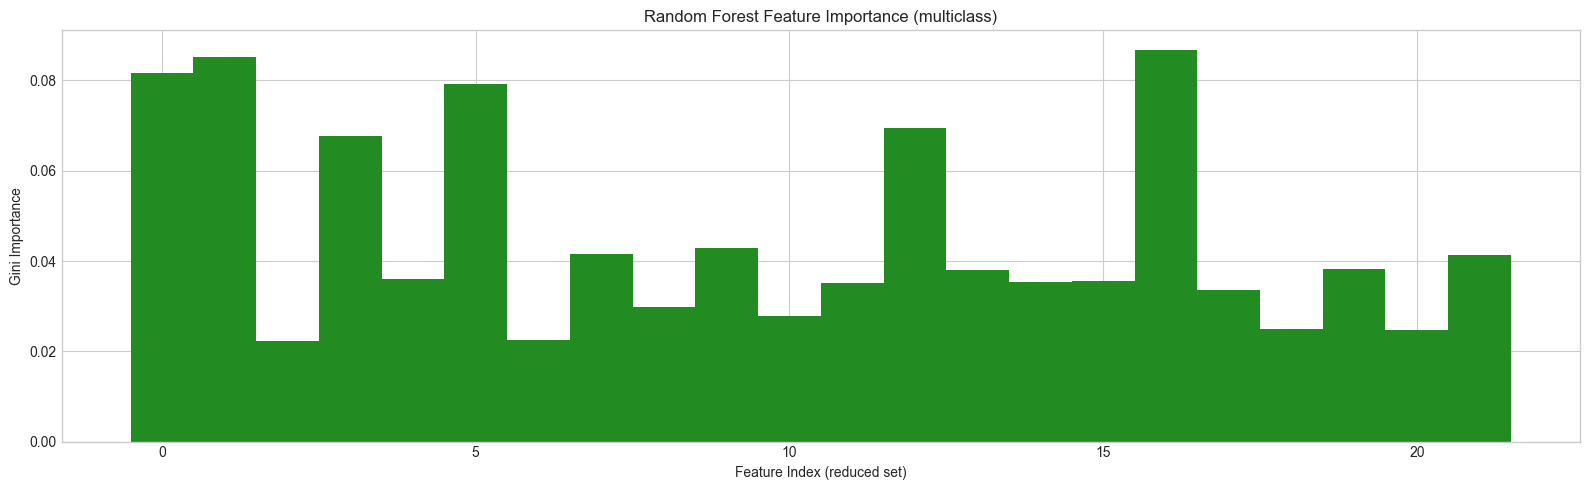


Top-10 RF-important features (reduced idx): [16  1  0  5 12  3  9  7 21 19]
Top-10 RF-important features (original idx): [181, 6, 0, 69, 125, 61, 102, 90, 206, 196]
RF train accuracy: 1.0000


In [27]:
# --- Random Forest importance on the reduced feature set ---
rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_clean_reduced, y)

rf_importance = rf.feature_importances_

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(len(rf_importance)), rf_importance, width=1.0, color='forestgreen')
ax.set_xlabel('Feature Index (reduced set)')
ax.set_ylabel('Gini Importance')
ax.set_title('Random Forest Feature Importance (multiclass)')
plt.tight_layout()
plt.show()

top_rf_feats = np.argsort(rf_importance)[-10:][::-1]
print(f"\nTop-10 RF-important features (reduced idx): {top_rf_feats}")
print(f"Top-10 RF-important features (original idx): {[features_to_keep[i] for i in top_rf_feats]}")
print(f"RF train accuracy: {rf.score(X_clean_reduced, y):.4f}")

In [28]:
# --- Compare importance rankings across methods ---
importance_df = pd.DataFrame({
    'Feature (reduced)': range(X_clean_reduced.shape[1]),
    'Feature (original)': features_to_keep,
    'PCA importance': pca_importance,
    'LDA importance': lda_importance,
    'RF importance': rf_importance,
    'ANOVA F-stat': f_stats[features_to_keep] / f_stats[features_to_keep].max(),
})

# Rank correlation between methods
from scipy.stats import spearmanr
methods = ['PCA importance', 'LDA importance', 'RF importance', 'ANOVA F-stat']
print("Spearman rank correlation between importance methods:")
for i, m1 in enumerate(methods):
    for m2 in methods[i+1:]:
        corr_val, p = spearmanr(importance_df[m1], importance_df[m2])
        print(f"  {m1} vs {m2}: rho = {corr_val:.3f} (p = {p:.2e})")

# Consensus top features (appear in top-10 for at least 2 methods)
top_sets = [
    set(top_pca_feats),
    set(top_lda_feats),
    set(top_rf_feats),
    set(np.argsort(f_stats[features_to_keep])[-10:][::-1])
]
from collections import Counter
feat_votes = Counter()
for s in top_sets:
    feat_votes.update(s)

consensus_feats = [f for f, count in feat_votes.most_common() if count >= 2]
print(f"\nConsensus important features (top-10 in >=2 methods): {len(consensus_feats)}")
print(f"  Reduced indices: {consensus_feats[:15]}")
print(f"  Original indices: {[features_to_keep[i] for i in consensus_feats[:15]]}")

Spearman rank correlation between importance methods:
  PCA importance vs LDA importance: rho = -0.212 (p = 3.44e-01)
  PCA importance vs RF importance: rho = -0.257 (p = 2.48e-01)
  PCA importance vs ANOVA F-stat: rho = 0.747 (p = 6.48e-05)
  LDA importance vs RF importance: rho = -0.204 (p = 3.63e-01)
  LDA importance vs ANOVA F-stat: rho = -0.263 (p = 2.38e-01)
  RF importance vs ANOVA F-stat: rho = 0.101 (p = 6.54e-01)

Consensus important features (top-10 in >=2 methods): 13
  Reduced indices: [np.int64(1), np.int64(3), np.int64(7), np.int64(9), np.int64(14), np.int64(18), np.int64(2), np.int64(6), np.int64(10), np.int64(13), np.int64(5), np.int64(19), np.int64(20)]
  Original indices: [6, 61, 90, 102, 145, 185, 31, 87, 121, 133, 69, 196, 204]


## §8 – Output Cleaned Datasets

Save the following to `data/cleaned/`:
1. **Normalised + feature-reduced datasets** (correlated features removed, scaled to [-1, 1])
2. **Dimensionality-reduced datasets** (PCA, LDA, UMAP versions)
3. **Metadata** (feature indices kept, scaler parameters, DR model info)

In [29]:
# Save cleaned datasets as .mat files

# 1. Main cleaned dataset (normalised, redundant features removed)
cleaned_main = {
    'X_clean': X_clean_reduced,
    'X_noisy': X_noisy_reduced,
    'y': y,
    'features_kept': np.array(features_to_keep),
    'n_original_features': n_original,
    'n_samples': len(y),
    'n_classes': N_CLASSES,
    'class_names': np.array(CLASS_NAMES, dtype=object),
    'scaler_min': scaler.data_min_,
    'scaler_max': scaler.data_max_,
    'normalisation': 'minmax_-1_1',
}
sio.savemat(str(OUTPUT_DIR / 'eit_cleaned.mat'), cleaned_main)
print(f"Saved: {OUTPUT_DIR / 'eit_cleaned.mat'}")
print(f"  Shape: {X_clean_reduced.shape} (clean & noisy)")

# 2. PCA-reduced dataset
pca_data = {
    'X_clean': X_clean_pca,
    'X_noisy': X_noisy_pca,
    'y': y,
    'n_components': n_pca_95,
    'explained_variance_ratio': pca.explained_variance_ratio_,
    'method': 'PCA',
}
sio.savemat(str(OUTPUT_DIR / 'eit_cleaned_pca.mat'), pca_data)
print(f"\nSaved: {OUTPUT_DIR / 'eit_cleaned_pca.mat'}")
print(f"  Shape: {X_clean_pca.shape}, variance retained: {pca.explained_variance_ratio_.sum():.4f}")

# 3. LDA-reduced dataset
lda_data = {
    'X_clean': X_clean_lda,
    'X_noisy': X_noisy_lda,
    'y': y,
    'n_components': n_lda_components,
    'explained_variance_ratio': lda.explained_variance_ratio_,
    'method': 'LDA',
}
sio.savemat(str(OUTPUT_DIR / 'eit_cleaned_lda.mat'), lda_data)
print(f"\nSaved: {OUTPUT_DIR / 'eit_cleaned_lda.mat'}")
print(f"  Shape: {X_clean_lda.shape}")

# 4. UMAP-reduced dataset (if available)
if X_clean_umap is not None:
    umap_data = {
        'X_clean': X_clean_umap,
        'X_noisy': X_noisy_umap,
        'y': y,
        'n_components': n_umap_components,
        'method': 'UMAP',
    }
    sio.savemat(str(OUTPUT_DIR / 'eit_cleaned_umap.mat'), umap_data)
    print(f"\nSaved: {OUTPUT_DIR / 'eit_cleaned_umap.mat'}")
    print(f"  Shape: {X_clean_umap.shape}")

Saved: ..\data\cleaned\eit_cleaned.mat
  Shape: (24202, 22) (clean & noisy)

Saved: ..\data\cleaned\eit_cleaned_pca.mat
  Shape: (24202, 7), variance retained: 0.9638

Saved: ..\data\cleaned\eit_cleaned_lda.mat
  Shape: (24202, 4)

Saved: ..\data\cleaned\eit_cleaned_umap.mat
  Shape: (24202, 7)


In [30]:
# Summary of all outputs
print("=" * 60)
print("EDA COMPLETE - Cleaned Dataset Summary")
print("=" * 60)
print(f"\nOutput directory: {OUTPUT_DIR.resolve()}")
print(f"\nFiles produced:")
for f in sorted(OUTPUT_DIR.glob('*.mat')):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name} ({size_kb:.1f} KB)")

print(f"\n--- Pipeline Summary ---")
print(f"1. Loaded {len(y) + n_dup_clean} samples x {n_original} features")
print(f"2. Removed {n_dup_clean} exact duplicates -> {len(y)} samples")
print(f"3. Normalised features to [-1, 1] (per-feature Min-Max)")
print(f"4. Removed {len(features_to_drop)} redundant features (|r| >= 0.75) -> {len(features_to_keep)} features")
print(f"5. Applied dimensionality reduction:")
print(f"   - PCA: {n_pca_95} components (95% variance)")
print(f"   - LDA: {n_lda_components} components (supervised)")
if X_clean_umap is not None:
    print(f"   - UMAP: {n_umap_components} components")
print(f"\nAll datasets include both clean and noisy versions with aligned labels.")

EDA COMPLETE - Cleaned Dataset Summary

Output directory: C:\Users\ronaldp\Documents\Repos\eit-sim2real\data\cleaned

Files produced:
  eit_cleaned.mat (4351.9 KB)
  eit_cleaned_lda.mat (945.9 KB)
  eit_cleaned_pca.mat (1513.2 KB)
  eit_cleaned_umap.mat (1513.1 KB)

--- Pipeline Summary ---
1. Loaded 30000 samples x 208 features
2. Removed 5798 exact duplicates -> 24202 samples
3. Normalised features to [-1, 1] (per-feature Min-Max)
4. Removed 186 redundant features (|r| >= 0.75) -> 22 features
5. Applied dimensionality reduction:
   - PCA: 7 components (95% variance)
   - LDA: 4 components (supervised)
   - UMAP: 7 components

All datasets include both clean and noisy versions with aligned labels.
